Analysis (Next Step):
1. 模型学习出来的embedding 好，可视化，numerical metric；
2. 类似的Binding 任务。（A+B）
3. 对比不同unseen ratio 下pretrain 的结果，证明LLM 可以处理 zero-shot 的setting


What is CTT?



In [7]:
import numpy as np
from scipy.spatial.distance import cdist

def calculate_ctt_score(vector_embeddings):
    N = len(vector_embeddings)
    N_T = int(0.1 * N)  # 10% of N

    # Step 1 & 2: Compute D_T
    test_indices = np.random.choice(N, N_T, replace=False)
    test_points = vector_embeddings[test_indices]
    distances_to_all = cdist(test_points, vector_embeddings, 'euclidean')

    for i in range(N_T):
        distances_to_all[i, test_indices[i]] = np.inf # To exclude distance to itself

    D_T = np.min(distances_to_all, axis=1).sum()

    # Step 3: Select N_T random vectors from the given vector_embeddings
    random_indices = np.random.choice(N, N_T, replace=False)
    random_points = vector_embeddings[random_indices]

    # print(test_indices)
    # print(random_indices)

    # Step 4: Compute D_R (now with selected random points from the embeddings)
    distances_to_all_random = cdist(random_points, vector_embeddings, 'euclidean')

    for i in range(N_T):
        distances_to_all_random[i, random_indices[i]] = np.inf # To exclude distance to itself

    D_R = np.min(distances_to_all_random, axis=1).sum()

    # print(f"D_T: {D_T}, D_R: {D_R}")

    # Step 5: Calculate CTT score
    ctt_score = D_R / (D_R + D_T)
    
    return ctt_score


In [2]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

def hopkins_statistic(X):
    n, d = X.shape
    m = int(0.1 * n)  # Use 10% of the data as the sample size
    nbrs = NearestNeighbors(n_neighbors=1, metric = "euclidean").fit(X)
    
    rand_X = np.random.uniform(np.min(X, axis=0), np.max(X, axis=0), (m, d))
    
    u_dist, _ = nbrs.kneighbors(rand_X, n_neighbors=2)
    u_dist = u_dist[:, 1]  # Distance to the nearest neighbor in the actual data
    w_dist, _ = nbrs.kneighbors(X[np.random.choice(n, m, replace=False)], n_neighbors=2)
    w_dist = w_dist[:, 1]  # Distance to the nearest neighbor in the sample
    
    H = sum(u_dist) / (sum(u_dist) + sum(w_dist))
    return H


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def generate_clustered_data(centers, num_points_per_cluster, cluster_std):
    """
    Generate clustered data manually.

    :param centers: A list of tuples representing the coordinates of cluster centers.
    :param num_points_per_cluster: Number of points to generate per cluster.
    :param cluster_std: Standard deviation to use for generating points around the cluster centers.
    :return: A numpy array containing the generated points.
    """
    data = []
    for center in centers:
        # For each center, generate 'num_points_per_cluster' points
        points = np.random.randn(num_points_per_cluster, len(center)) * cluster_std + center
        data.append(points)
    return np.vstack(data)  # Combine all clusters into one array


# Generate manually clustered data
centers = [(0, 0), (5, 5), (10, 0)]
num_points_per_cluster = 50
cluster_std = 1.0
clustered_data_manual = generate_clustered_data(centers, num_points_per_cluster, cluster_std)


In [13]:
import numpy as np
from sklearn.datasets import make_blobs

# def test_calculate_ctt_score():
    # Scenario 1: Uniform Distribution
uniform_data = np.random.rand(1000, 10)  # 100 points in 2D
# print(uniform_data)
uniform_ctt_score = calculate_ctt_score(uniform_data)
uniform_h_score = hopkins_statistic(uniform_data)
print(f"CTT Score for Uniform Distribution: {uniform_ctt_score}")
print(f"Hopkins Score for Uniform Distribution: {uniform_h_score}")
assert 0.4 <= uniform_ctt_score <= 0.6, "CTT score for uniform distribution should be around 0.5"
assert 0.4 <= uniform_h_score <= 0.6, "Hopkins score for uniform distribution should be around 0.5"

# Scenario 2: Clustered Data
# clustered_data, _ = make_blobs(n_samples=1000, centers=3, n_features=10, cluster_std=1, random_state=42)
clustered_ctt_score = calculate_ctt_score(clustered_data_manual)
clustered_h_score = hopkins_statistic(clustered_data_manual)
print(f"CTT Score for Clustered Data: {clustered_ctt_score}")
print(f"Hopkins Score for Clustered Data: {clustered_h_score}")
assert clustered_ctt_score > 0.6, "CTT score for clustered data should be significantly higher than 0.5"
assert clustered_h_score > 0.6, "Hopkins score for clustered data should be significantly higher than 0.5"

# test_calculate_ctt_score()


CTT Score for Uniform Distribution: 0.5016540994569506
Hopkins Score for Uniform Distribution: 0.5333397732002926
CTT Score for Clustered Data: 0.4903278081186249
Hopkins Score for Clustered Data: 0.8535551992879195


AssertionError: CTT score for clustered data should be significantly higher than 0.5

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.manifold import TSNE

def visualize_with_tsne(data, title):
    # Apply t-SNE to reduce data to two dimensions
    tsne = TSNE(n_components=2, random_state=42)
    data_2d = tsne.fit_transform(data)
    
    # Plot the data
    plt.figure(figsize=(8, 6))
    plt.scatter(data_2d[:, 0], data_2d[:, 1])
    plt.title(title)
    plt.xlabel('t-SNE Feature 1') 
    plt.ylabel('t-SNE Feature 2')
    plt.show()

visualize_with_tsne(uniform_data, f"uniform_data, H score: {uniform_ctt_score}")
visualize_with_tsne(clustered_data_manual, f"clustered_data_manual, H score: {clustered_ctt_score}")


In [1]:
import numpy as np
from scipy.spatial import distance

def compute_cts(embeddings, N_S=10000, N_T=1000):
    # Sample N_S embeddings from the given set
    sampled_indices = np.random.choice(len(embeddings), N_S, replace=False)
    Q = embeddings[sampled_indices]
    
    # Subsample N_T embeddings as test points
    test_indices = np.random.choice(N_S, N_T, replace=False)
    T = Q[test_indices]
    
    # Calculate DT
    DT = 0
    for q_i_star in T:
        distances = distance.cdist([q_i_star], Q, 'sqeuclidean')[0]
        distances[test_indices[np.where(T == q_i_star)[0][0]]] = np.inf  # exclude self
        DT += np.min(distances)
    
    # Generate NT random points
    q_min = np.min(Q, axis=0)
    q_max = np.max(Q, axis=0)
    U = np.random.uniform(q_min, q_max, (N_T, Q.shape[1]))
    
    # Calculate DR
    DR = 0
    for u_i in U:
        distances = distance.cdist([u_i], Q, 'sqeuclidean')[0]
        DR += np.min(distances)
    
    # Compute CTS
    CTS = 2 * max(DR / (DR + DT) - 0.5, 0)
    
    return CTS

# Generate synthetic data for testing
np.random.seed(42)
N = 20000  # Total number of embeddings
dim = 10   # Dimensionality of embeddings

# Generate clustered data
cluster1 = np.random.randn(N // 2, dim) + np.array([5] * dim)
cluster2 = np.random.randn(N // 2, dim) + np.array([-5] * dim)
embeddings = np.vstack([cluster1, cluster2])

# Compute CTS
cts_value = compute_cts(embeddings)
print(f"Cluster Tendency Score (CTS): {cts_value:.4f}")

Cluster Tendency Score (CTS): 0.9802


In [2]:
import numpy as np
from scipy.spatial import distance

def compute_cts(embeddings, N_S=10000, N_T=1000):
    # Sample N_S embeddings from the given set
    sampled_indices = np.random.choice(len(embeddings), N_S, replace=False)
    Q = embeddings[sampled_indices]
    
    # Subsample N_T embeddings as test points
    test_indices = np.random.choice(N_S, N_T, replace=False)
    T = Q[test_indices]
    
    # Calculate DT
    DT = 0
    for q_i_star in T:
        distances = distance.cdist([q_i_star], Q, 'sqeuclidean')[0]
        distances[test_indices[np.where(T == q_i_star)[0][0]]] = np.inf  # exclude self
        DT += np.min(distances)
    
    # Generate NT random points
    q_min = np.min(Q, axis=0)
    q_max = np.max(Q, axis=0)
    U = np.random.uniform(q_min, q_max, (N_T, Q.shape[1]))
    
    # Calculate DR
    DR = 0
    for u_i in U:
        distances = distance.cdist([u_i], Q, 'sqeuclidean')[0]
        DR += np.min(distances)
    
    # Compute CTS
    CTS = 2 * max(DR / (DR + DT) - 0.5, 0)
    
    return CTS

# Generate synthetic data for testing
np.random.seed(42)
N = 20000  # Total number of embeddings
dim = 10   # Dimensionality of embeddings

# Generate clustered data
cluster1 = np.random.randn(N // 2, dim) + np.array([5] * dim)
cluster2 = np.random.randn(N // 2, dim) + np.array([-5] * dim)
embeddings_clustered = np.vstack([cluster1, cluster2])

# Compute CTS for clustered data
cts_clustered = compute_cts(embeddings_clustered)
print(f"Cluster Tendency Score (CTS) for clustered data: {cts_clustered:.4f}")

# Generate uniformly distributed data
embeddings_uniform = np.random.uniform(-10, 10, (N, dim))

# Compute CTS for uniformly distributed data
cts_uniform = compute_cts(embeddings_uniform)
print(f"Cluster Tendency Score (CTS) for uniformly distributed data: {cts_uniform:.4f}")

Cluster Tendency Score (CTS) for clustered data: 0.9802
Cluster Tendency Score (CTS) for uniformly distributed data: 0.0071


Cluster Tendency Score (CTS) for clustered data: 0.9802
Cluster Tendency Score (CTS) for uniformly distributed data: 0.0071


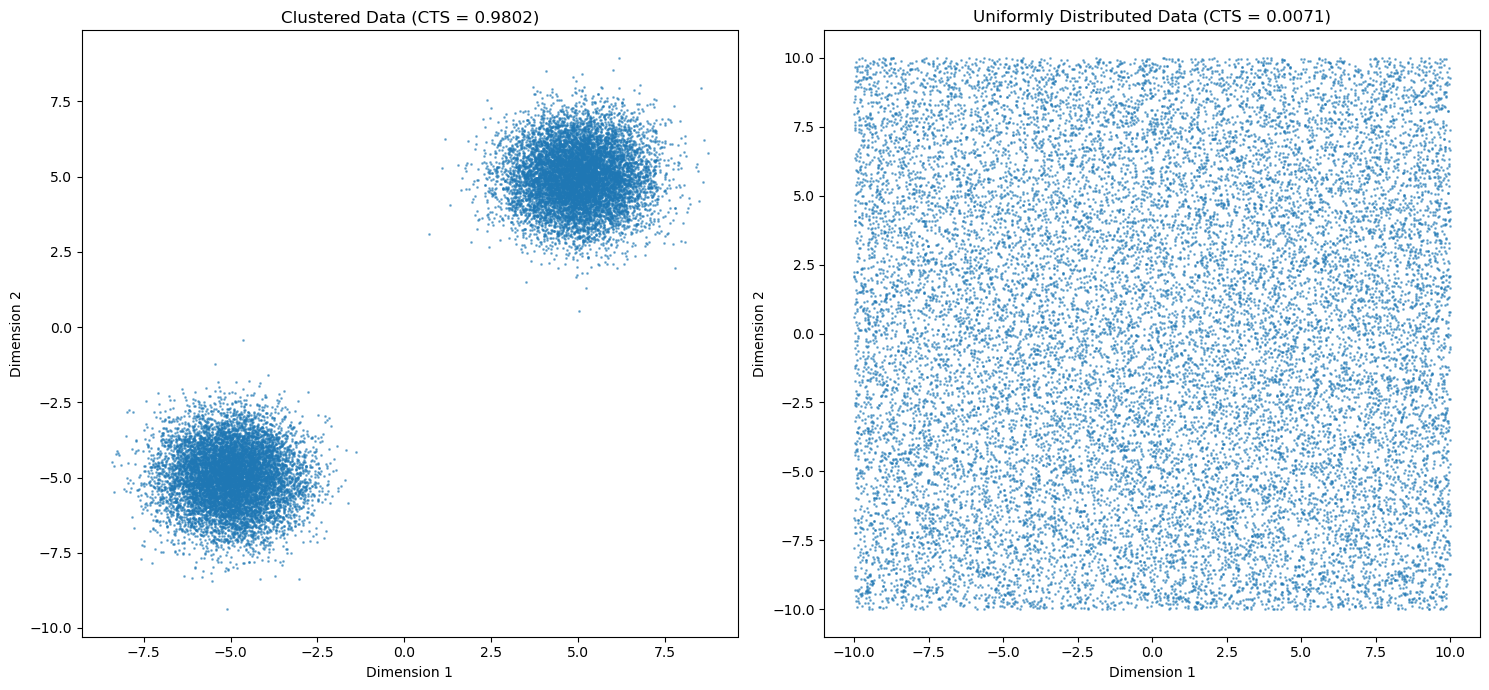

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance

def compute_cts(embeddings, N_S=10000, N_T=1000):
    # Sample N_S embeddings from the given set
    sampled_indices = np.random.choice(len(embeddings), N_S, replace=False)
    Q = embeddings[sampled_indices]
    
    # Subsample N_T embeddings as test points
    test_indices = np.random.choice(N_S, N_T, replace=False)
    T = Q[test_indices]
    
    # Calculate DT
    DT = 0
    for q_i_star in T:
        distances = distance.cdist([q_i_star], Q, 'sqeuclidean')[0]
        distances[test_indices[np.where(T == q_i_star)[0][0]]] = np.inf  # exclude self
        DT += np.min(distances)
    
    # Generate NT random points
    q_min = np.min(Q, axis=0)
    q_max = np.max(Q, axis=0)
    U = np.random.uniform(q_min, q_max, (N_T, Q.shape[1]))
    
    # Calculate DR
    DR = 0
    for u_i in U:
        distances = distance.cdist([u_i], Q, 'sqeuclidean')[0]
        DR += np.min(distances)
    
    # Compute CTS
    CTS = 2 * max(DR / (DR + DT) - 0.5, 0)
    
    return CTS

# Generate synthetic data for testing
np.random.seed(42)
N = 20000  # Total number of embeddings
dim = 10   # Dimensionality of embeddings

# Generate clustered data
cluster1 = np.random.randn(N // 2, dim) + np.array([5] * dim)
cluster2 = np.random.randn(N // 2, dim) + np.array([-5] * dim)
embeddings_clustered = np.vstack([cluster1, cluster2])

# Compute CTS for clustered data
cts_clustered = compute_cts(embeddings_clustered)
print(f"Cluster Tendency Score (CTS) for clustered data: {cts_clustered:.4f}")

# Generate uniformly distributed data
embeddings_uniform = np.random.uniform(-10, 10, (N, dim))

# Compute CTS for uniformly distributed data
cts_uniform = compute_cts(embeddings_uniform)
print(f"Cluster Tendency Score (CTS) for uniformly distributed data: {cts_uniform:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Plot clustered data
axes[0].scatter(embeddings_clustered[:, 0], embeddings_clustered[:, 1], s=1, alpha=0.5)
axes[0].set_title(f'Clustered Data (CTS = {cts_clustered:.4f})')
axes[0].set_xlabel('Dimension 1')
axes[0].set_ylabel('Dimension 2')

# Plot uniformly distributed data
axes[1].scatter(embeddings_uniform[:, 0], embeddings_uniform[:, 1], s=1, alpha=0.5)
axes[1].set_title(f'Uniformly Distributed Data (CTS = {cts_uniform:.4f})')
axes[1].set_xlabel('Dimension 1')
axes[1].set_ylabel('Dimension 2')

plt.tight_layout()
plt.show()

Cluster Tendency Score (CTS) for clustered data: 0.8275
Cluster Tendency Score (CTS) for uniformly distributed data: 0.0071


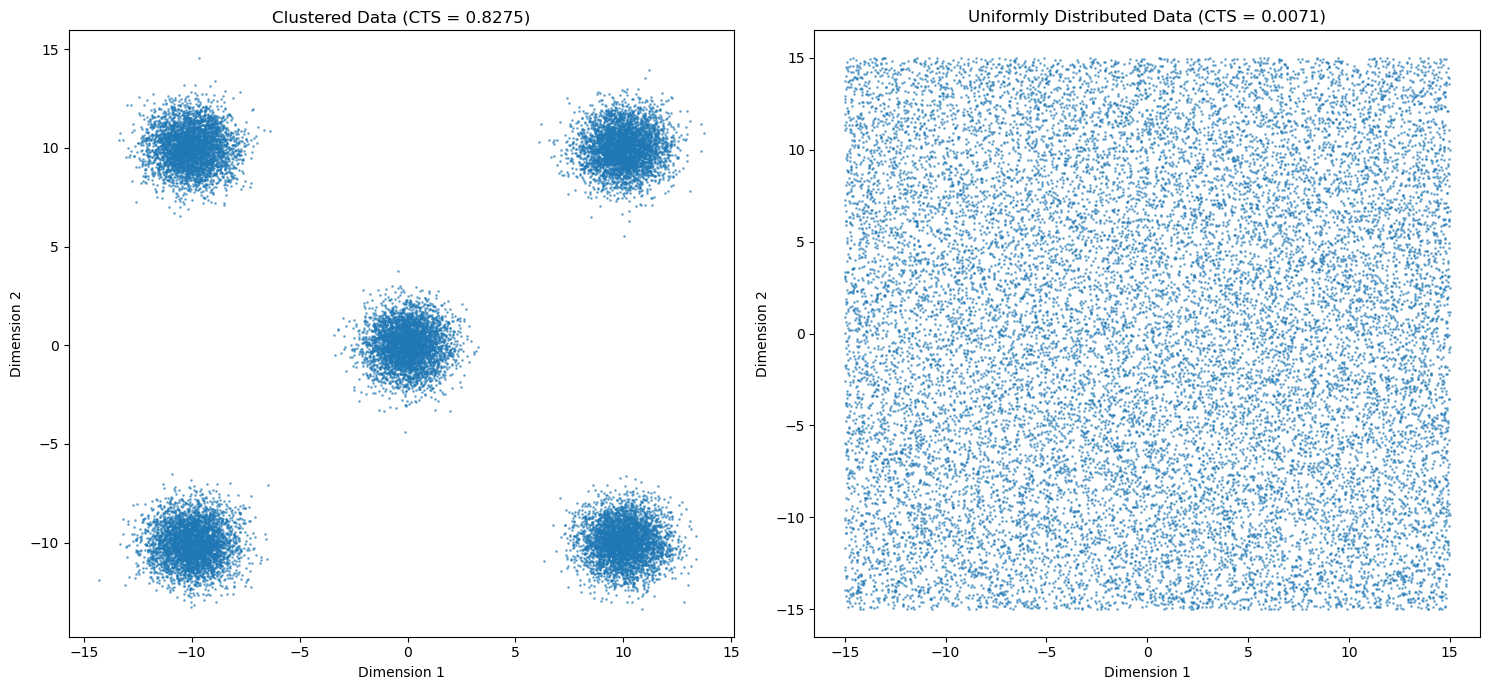

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance

def compute_cts(embeddings, N_S=10000, N_T=1000):
    # Sample N_S embeddings from the given set
    sampled_indices = np.random.choice(len(embeddings), N_S, replace=False)
    Q = embeddings[sampled_indices]
    
    # Subsample N_T embeddings as test points
    test_indices = np.random.choice(N_S, N_T, replace=False)
    T = Q[test_indices]
    
    # Calculate DT
    DT = 0
    for q_i_star in T:
        distances = distance.cdist([q_i_star], Q, 'sqeuclidean')[0]
        distances[test_indices[np.where(T == q_i_star)[0][0]]] = np.inf  # exclude self
        DT += np.min(distances)
    
    # Generate NT random points
    q_min = np.min(Q, axis=0)
    q_max = np.max(Q, axis=0)
    U = np.random.uniform(q_min, q_max, (N_T, Q.shape[1]))
    
    # Calculate DR
    DR = 0
    for u_i in U:
        distances = distance.cdist([u_i], Q, 'sqeuclidean')[0]
        DR += np.min(distances)
    
    # Compute CTS
    CTS = 2 * max(DR / (DR + DT) - 0.5, 0)
    
    return CTS

# Generate synthetic data for testing
np.random.seed(42)
N = 20000  # Total number of embeddings
dim = 10   # Dimensionality of embeddings

# Generate data with 5 clusters
clusters = []
centers = np.array([[10, 10], [-10, -10], [10, -10], [-10, 10], [0, 0]])  # Centers of 5 clusters
for center in centers:
    cluster = np.random.randn(N // 5, dim) + np.pad(center, (0, dim - len(center)), 'constant')
    clusters.append(cluster)
embeddings_clustered = np.vstack(clusters)

# Compute CTS for clustered data
cts_clustered = compute_cts(embeddings_clustered)
print(f"Cluster Tendency Score (CTS) for clustered data: {cts_clustered:.4f}")

# Generate uniformly distributed data
embeddings_uniform = np.random.uniform(-15, 15, (N, dim))

# Compute CTS for uniformly distributed data
cts_uniform = compute_cts(embeddings_uniform)
print(f"Cluster Tendency Score (CTS) for uniformly distributed data: {cts_uniform:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Plot clustered data
axes[0].scatter(embeddings_clustered[:, 0], embeddings_clustered[:, 1], s=1, alpha=0.5)
axes[0].set_title(f'Clustered Data (CTS = {cts_clustered:.4f})')
axes[0].set_xlabel('Dimension 1')
axes[0].set_ylabel('Dimension 2')

# Plot uniformly distributed data
axes[1].scatter(embeddings_uniform[:, 0], embeddings_uniform[:, 1], s=1, alpha=0.5)
axes[1].set_title(f'Uniformly Distributed Data (CTS = {cts_uniform:.4f})')
axes[1].set_xlabel('Dimension 1')
axes[1].set_ylabel('Dimension 2')

plt.tight_layout()
plt.show()